<a href="https://colab.research.google.com/github/tharunteja20/CodeAlpha_DataAnalysis-/blob/main/CodeAlpha_DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load Titanic dataset
df = sns.load_dataset("titanic")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

# Cleaning missing values
df["age"] = df["age"].fillna(df["age"].median())
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df.drop(columns=["deck"], inplace=True)

print("\n--- Cleaned Missing Values ---")
print(df.isnull().sum())

--- Missing Values ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

--- Summary Statistics ---
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.0000

/tmp/ipykernel_1712/3551665393.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="survived", data=df, palette="Blues_d")


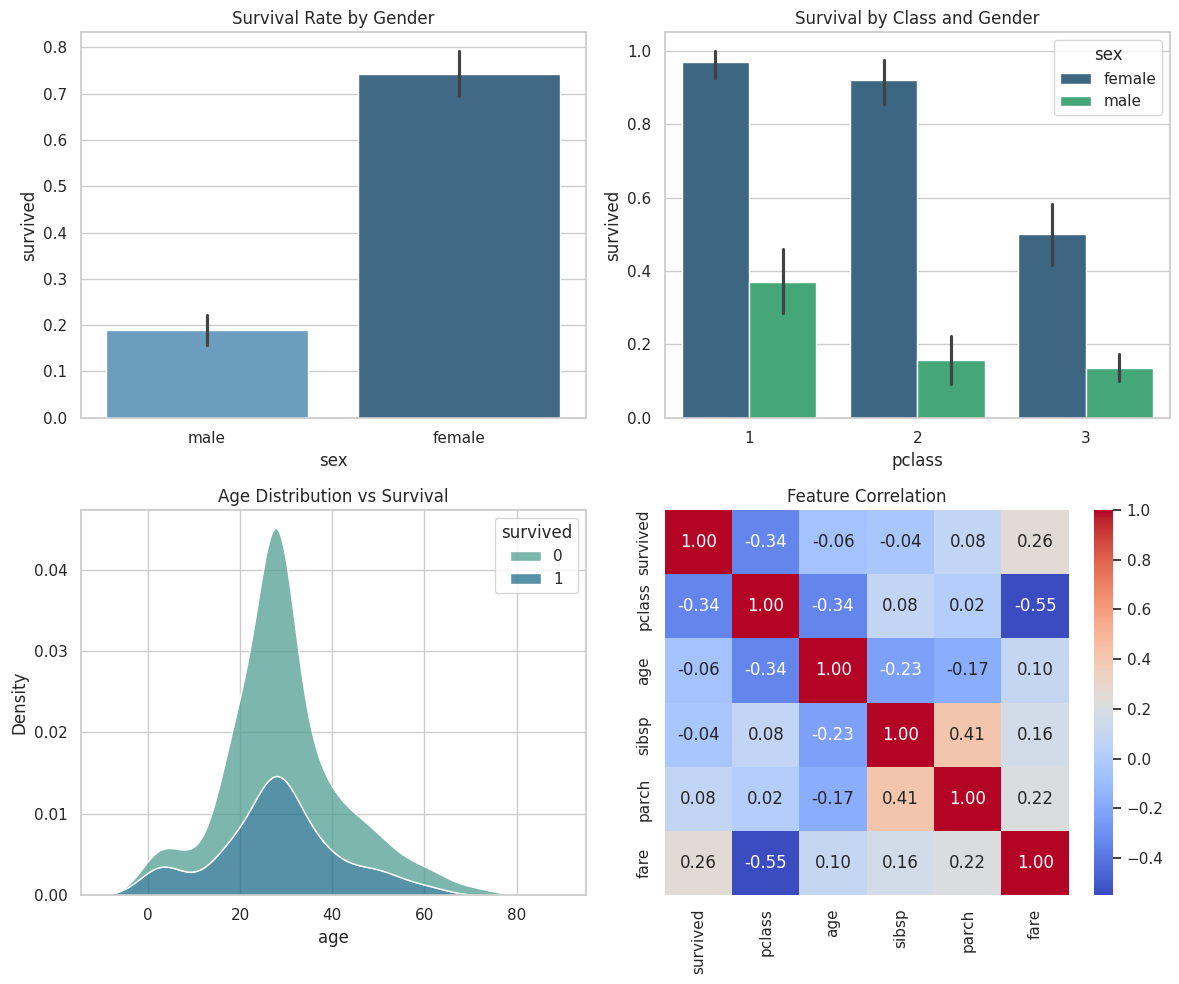

In [3]:
plt.figure(figsize=(12, 10))

# 1. Survival Rate by Gender
plt.subplot(2, 2, 1)
sns.barplot(x="sex", y="survived", data=df, palette="Blues_d")
plt.title("Survival Rate by Gender")

# 2. Survival Rate by Class
plt.subplot(2, 2, 2)
sns.barplot(x="pclass", y="survived", hue="sex", data=df, palette="viridis")
plt.title("Survival by Class and Gender")

# 3. Age Distribution by Survival
plt.subplot(2, 2, 3)
sns.kdeplot(
    data=df, x="age", hue="survived", multiple="stack", palette="crest"
)
plt.title("Age Distribution vs Survival")

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation")

plt.tight_layout()
plt.show()